In [1]:
import pandas as pd

In [2]:
file = pd.read_csv("../data/raw/openaccess/MetObjects.csv")
file.shape

C:\Users\Sahil\AppData\Local\Temp\ipykernel_29120\3336156477.py:1: DtypeWarning: Columns (5: Gallery Number, 7: AccessionYear, 10: Culture, 11: Period, 12: Dynasty, 13: Reign, 14: Portfolio, 34: Geography Type, 35: City, 36: State, 37: County, 38: Country, 39: Region, 40: Subregion, 41: Locale, 42: Locus, 43: Excavation, 44: River, 45: Classification, 46: Rights and Reproduction) have mixed types. Specify dtype option on import or set low_memory=False.
  file = pd.read_csv("../data/raw/openaccess/MetObjects.csv")


(484956, 54)

In [10]:
file.head()

,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979.0,Coin,One-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980.0,Coin,Ten-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
3,67.265.10,False,False,False,4,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/4,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
4,67.265.11,False,False,False,5,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/5,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN


In [11]:
file.info()

<class 'pandas.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 54 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Object Number            484956 non-null  str    
 1   Is Highlight             484956 non-null  bool   
 2   Is Timeline Work         484956 non-null  bool   
 3   Is Public Domain         484956 non-null  bool   
 4   Object ID                484956 non-null  int64  
 5   Gallery Number           49541 non-null   object 
 6   Department               484956 non-null  str    
 7   AccessionYear            481094 non-null  object 
 8   Object Name              482690 non-null  str    
 9   Title                    456153 non-null  str    
 10  Culture                  208190 non-null  str    
 11  Period                   91143 non-null   object 
 12  Dynasty                  23201 non-null   str    
 13  Reign                    11236 non-null   str    
 14  Portfolio      

In [16]:
cols = ["Object ID", "Title", "Object Name", "Culture", "Period", "Dynasty",
        "Artist Display Name", "Artist Nationality", "Object Date", "Medium",
        "Classification", "Department", "Tags", "Country"]

for i, row in file[cols].head(3).iterrows():
    print(f"--- row {i} ---")
    for col in cols:
        print(f"{col}: {row[col]}")
    print()

--- row 0 ---
Object ID: 1
Title: One-dollar Liberty Head Coin
Object Name: Coin
Culture: nan
Period: nan
Dynasty: nan
Artist Display Name: James Barton Longacre
Artist Nationality: American
Object Date: 1853
Medium: Gold
Classification: nan
Department: The American Wing
Tags: nan
Country: nan

--- row 1 ---
Object ID: 2
Title: Ten-dollar Liberty Head Coin
Object Name: Coin
Culture: nan
Period: nan
Dynasty: nan
Artist Display Name: Christian Gobrecht
Artist Nationality: American
Object Date: 1901
Medium: Gold
Classification: nan
Department: The American Wing
Tags: nan
Country: nan

--- row 2 ---
Object ID: 3
Title: Two-and-a-Half Dollar Coin
Object Name: Coin
Culture: nan
Period: nan
Dynasty: nan
Artist Display Name: nan
Artist Nationality: nan
Object Date: 1909–27
Medium: Gold
Classification: nan
Department: The American Wing
Tags: nan
Country: nan



In [8]:
to_keep = file.loc[(file["Department"].isin(["Asian Art", "European Paintings"])) & (file["Is Public Domain"] == True)]
to_keep.shape

(33622, 54)

In [10]:
cols_to_keep = ["Object ID", "Title", "Artist Display Name", "Object Date", "Medium", "Culture", "Credit Line", "Department"]

candidate_df = to_keep[cols_to_keep]
candidate_df.head()

,Object ID,Title,Artist Display Name,Object Date,Medium,Culture,Credit Line,Department
30295,35966,NaN,NaN,18th–19th century,Leather,Japan,"Gift of Mr. and Mrs. H. O. Havemeyer, 1896",Asian Art
30296,35967,NaN,NaN,18th century or earlier,Paint; on leather,China,"Gift of Mr. and Mrs. H. O. Havemeyer, 1896",Asian Art
30297,35968,清 佚名 台南地區荷蘭城堡|Forts Zeelandia and Provintia ...,Unidentified artist,19th century,Wall hanging; ink and color on deerskin,China,"Gift of J. Pierpont Morgan, 1909",Asian Art
30299,35970,明 丁雲鵬 潯陽送客圖 軸|Song of the Lute,Ding Yunpeng,1585,Hanging scroll; ink and color on paper,China,"John Stewart Kennedy Fund, 1913",Asian Art
30300,35971,清 佚名 倣王翬 倣李成山水圖 軸|Landscape after Li C...,Wang Hui|Unidentified artist,"18th century or later, spurious date of 1680",Hanging scroll; ink on silk,China,"John Stewart Kennedy Fund, 1913",Asian Art


In [11]:
candidate_df["Culture"].unique()

<StringArray>
[                                          'Japan',
                                           'China',
                                           'Korea',
                                     'North China',
 'China (Xinjiang Autonomous Region, Turfan area)',
                                  'China or Japan',
                               'India, Tamil Nadu',
                                        'Thailand',
           'Pakistan (ancient region of Gandhara)',
                                           'India',
 ...
               'North Central Thailand, Sukhothai',
                      'Vietnam, Hong River region',
                       'Myanmar (Burma), Mandalay',
                          'South India, Karnataka',
                  'Kashmir style in Western Tibet',
                      'India, Madurai, Tamil Nadu',
              'India, Kolkata (formerly Calcutta)',
           'South India, Andhra Pradesh, Tirupati',
                           'Eastern India, Od

In [7]:
candidate_df.to_csv("../data/processed/candidates.csv", index=False)

NameError: name 'candidate_df' is not defined

In [1]:
import sys
sys.path.append("..")

import pandas as pd
from src.dossier import build_dossier, UnusableRecordError

candidates = pd.read_csv("../data/processed/candidates.csv")
sample_ids = candidates["Object ID"].head(5).tolist()

for oid in sample_ids:
    try:
        print(build_dossier(oid))
    except UnusableRecordError as e:
        print(f"Skipped: {e}")

object_id=35966 title='Piece' artist=None date='18th–19th century' medium='Leather' department='Asian Art' credit_line='Gift of Mr. and Mrs. H. O. Havemeyer, 1896' image_url='https://images.metmuseum.org/CRDImages/as/original/DP11408.jpg' is_public_domain=True
object_id=35967 title='Panel' artist=None date='18th century or earlier' medium='Paint; on leather' department='Asian Art' credit_line='Gift of Mr. and Mrs. H. O. Havemeyer, 1896' image_url='https://images.metmuseum.org/CRDImages/as/original/DP11577.jpg' is_public_domain=True
object_id=35968 title='Forts Zeelandia and Provintia and the City of Tainan' artist='Unidentified artist' date='19th century' medium='Wall hanging; ink and color on deerskin' department='Asian Art' credit_line='Gift of J. Pierpont Morgan, 1909' image_url='https://images.metmuseum.org/CRDImages/as/original/DP354272.jpg' is_public_domain=True
object_id=35970 title='Song of the Lute' artist='Ding Yunpeng' date='1585' medium='Hanging scroll; ink and color on pap

In [3]:
for oid in sample_ids:
    result = multi_agent_graph.invoke({
        "object_id": oid, "raw_data": None, "error": None, "dossier": None,
        "date_verdict": None, "culture_verdict": None, "medium_verdict": None,
        "assessment": None, "correction": None,
    })
    print(oid, result["assessment"].flag, result.get("correction"))

35966 False None
35967 False None
35968 False None
35970 False None
35971 False None


In [3]:
from src.schema import ArtworkDossier
from src.agents import date_specialist, supervisor

fake_dossier = ArtworkDossier(
    object_id=999999,
    title="Portrait of a Nobleman",
    artist="Unknown",
    date="dated 1450, painted in 1850",
    medium="Oil on canvas",
    department="European Paintings",
    credit_line="Fictional Test Fund, 2024",
    image_url="https://example.com/fake.jpg",
    is_public_domain=True,
)

print(date_specialist(fake_dossier))

print(supervisor(fake_dossier))

date_conflict=True reason="The record states 'dated 1450, painted in 1850', which presents two conflicting dates without any resolution or explanation."
flag=True reason="[date] The record states 'dated 1450, painted in 1850', which presents two conflicting dates without any resolution or explanation." confidence='High'


In [4]:
from langgraph.types import Command
from src.multiagent_workflow import review_graph_compiled

config = {"configurable": {"thread_id": "fake-test-1"}}

initial_state = {
    "object_id": fake_dossier.object_id, "raw_data": None, "error": None,
    "dossier": fake_dossier, "date_verdict": None, "culture_verdict": None,
    "medium_verdict": None, "assessment": None, "correction": None, "human_decision": None,
}

result = review_graph_compiled.invoke(initial_state, config=config)
print(result)

{'object_id': 999999, 'raw_data': None, 'error': None, 'dossier': ArtworkDossier(object_id=999999, title='Portrait of a Nobleman', artist='Unknown', date='dated 1450, painted in 1850', medium='Oil on canvas', department='European Paintings', credit_line='Fictional Test Fund, 2024', image_url='https://example.com/fake.jpg', is_public_domain=True), 'date_verdict': DateVerdict(date_conflict=True, reason="The record states 'dated 1450, painted in 1850', which presents two conflicting dates without any resolution or explanation."), 'culture_verdict': CultureVerdict(department_culture_mismatch=False, reason="The department 'European Paintings' is appropriate for the artwork titled 'Portrait of a Nobleman', which is an oil painting dated to 1450 and painted in 1850."), 'medium_verdict': MediumVerdict(medium_anachronism=False, reason="The medium 'Oil on canvas' was commonly used during the time period of 1850, and it is not rare in the European Paintings department."), 'assessment': Artworkass

In [3]:
import sys
sys.path.append("..")

from dotenv import load_dotenv
load_dotenv()

from src.workflow import dossier_graph

import logging
logging.getLogger("langsmith").setLevel(logging.WARNING)


for oid in sample_ids:
    result = dossier_graph.invoke({"object_id": oid, "raw_data": None, "error": None, "dossier": None})
    a = result["assessment"]
    print(oid, a.flag, a.confidence, "-", a.reason)

Object 35966: tool_calls = [{'name': 'check_medium_frequency', 'args': {'department': 'Asian Art', 'medium_keyword': 'Leather'}, 'id': 'call_GMbMG8aCvwxAJAp6tiROCENn', 'type': 'tool_call'}]
Object 35966: reason = 'No contradiction was found.'
Object 35966: routing -> clean
35966 False High - No contradiction was found.
Object 35967: tool_calls = [{'name': 'check_medium_frequency', 'args': {'department': 'Asian Art', 'medium_keyword': 'leather'}, 'id': 'call_2FKGwoqxhZLAVsQ4n4SofL1K', 'type': 'tool_call'}, {'name': 'check_medium_frequency', 'args': {'department': 'Asian Art', 'medium_keyword': 'paint'}, 'id': 'call_JF5xqNeob707xjZSbWKNIx5w', 'type': 'tool_call'}]
Object 35967: reason = 'No contradiction was found.'
Object 35967: routing -> clean
35967 False high - No contradiction was found.
Object 35968: tool_calls = [{'name': 'check_medium_frequency', 'args': {'department': 'Asian Art', 'medium_keyword': 'deerskin'}, 'id': 'call_jE5ogyrlUCAYmkBuPWedGp86', 'type': 'tool_call'}]
Object 

In [17]:
import sys
sys.path.append("..")

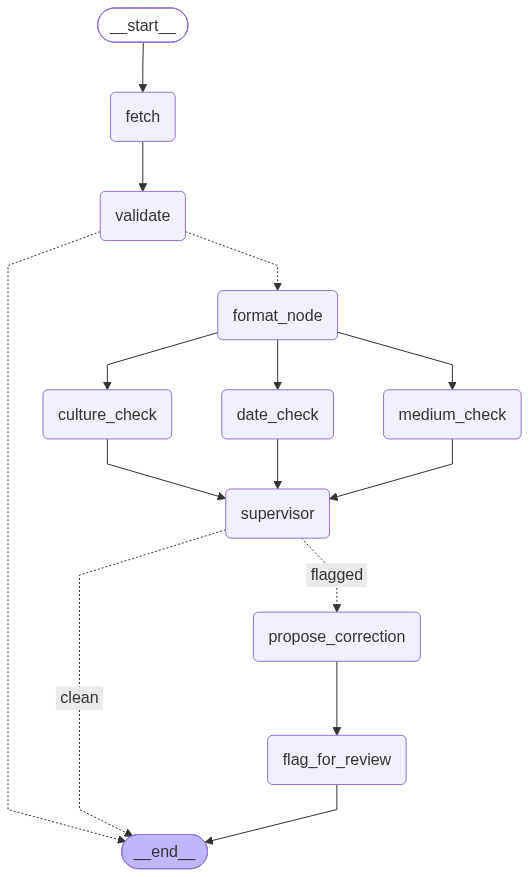

In [20]:
from dotenv import load_dotenv

import sys
sys.path.append("..")
load_dotenv()

from src.detective.workflow import dossier_graph

from src.detective.multiagent_workflow import multi_agent_graph

multi_agent_graph

## Curator part

In [1]:
import sys
sys.path.append("..")

In [3]:
public_df = file.loc[file["Is Public Domain"] == True].reset_index(drop=True)
public_df.shape

(248472, 54)

In [4]:
EMBED_FIELDS = [
    "Title", "Object Name", "Culture", "Period", "Dynasty",
    "Artist Display Name", "Artist Nationality", "Object Date",
    "Medium", "Classification", "Department", "Tags", "Country",
]

def build_embedding_text(row: pd.Series) -> str:
    parts = []
    for field in EMBED_FIELDS:
        value = row.get(field)
        if pd.notna(value) and str(value).strip():
            parts.append(f"{field}: {value}")
    return ". ".join(parts)

In [7]:
public_df["embedding_text"] = public_df.apply(build_embedding_text, axis=1)
for t in public_df["embedding_text"].sample(5, random_state=1):
    print(t)
    print("---")

Object Name: Bowl base. Culture: Indonesia (Java). Period: Eastern Javanese period. Object Date: 8th–early 10th century. Medium: Gold. Classification: Metalwork. Department: Asian Art
---
Object Name: Piece. Culture: Japan. Object Date: 18th–19th century. Medium: Silk. Classification: Textiles-Woven. Department: Asian Art
---
Object Name: Netsuke. Culture: Japan. Artist Display Name: Rensai. Artist Nationality: Japanese. Medium: Ivory. Classification: Netsuke. Department: Asian Art. Tags: Lions
---
Title: Brooch. Object Name: Brooch. Culture: European Bronze Age. Object Date: 8th century BCE. Medium: Copper alloy. Classification: Metalwork-Copper alloy. Department: Medieval Art. Tags: Brooches
---
Title: Central Mount of Purse. Object Name: Mount. Culture: Frankish. Object Date: 7th century (?). Medium: Silvered Copper alloy. Classification: Metalwork-Copper alloy. Department: Medieval Art. Country: Northern France (?)
---


In [3]:
from src.curator.index import search


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 434.65it/s]


c:\Users\Sahil\atelier\agent_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/MetObjects.csv'